# Лабораторная работа №5. Ансамблевые модели

Датасет **Penguins** — задача классификации видов пингвинов (Adelie, Chinstrap, Gentoo) по биометрическим признакам.

**Признаки:**
- `bill_length_mm`, `bill_depth_mm` — размеры клюва
- `flipper_length_mm` — длина ласта
- `body_mass_g` — масса тела
- `island` (категориальный) — остров обитания
- `sex` (категориальный) — пол

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from operator import itemgetter

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.ensemble import (
    BaggingClassifier,
    RandomForestClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier
)

%matplotlib inline
sns.set(style="ticks")

## 1. Загрузка и первичный анализ датасета

In [2]:
df = pd.read_csv('penguins.csv')
print('Форма датасета:', df.shape)
df.head(10)

Форма датасета: (344, 7)


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,MALE
6,Adelie,Torgersen,38.9,17.8,181.0,3625.0,FEMALE
7,Adelie,Torgersen,39.2,19.6,195.0,4675.0,MALE
8,Adelie,Torgersen,34.1,18.1,193.0,3475.0,NaN
9,Adelie,Torgersen,42.0,20.2,190.0,4250.0,NaN


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


In [4]:
df.describe()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
count,342.000000,342.000000,342.000000,342.000000
mean,43.921930,17.151170,200.915205,4201.754386
std,5.459584,1.974793,14.061714,801.954536
min,32.100000,13.100000,172.000000,2700.000000
25%,39.225000,15.600000,190.000000,3550.000000
50%,44.450000,17.300000,197.000000,4050.000000
75%,48.500000,18.700000,213.000000,4750.000000
max,59.600000,21.500000,231.000000,6300.000000


Распределение классов:
species
Adelie       152
Gentoo       124
Chinstrap     68
Name: count, dtype: int64


/var/folders/xq/4y5bcrd13nx5wpy_8xq987040000gn/T/ipykernel_36837/52587066.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='species', data=df, palette='Set2')


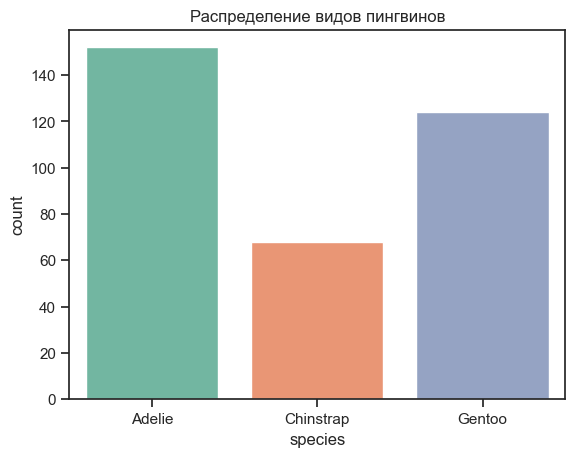

In [5]:
print('Распределение классов:')
print(df['species'].value_counts())

sns.countplot(x='species', data=df, palette='Set2')
plt.title('Распределение видов пингвинов')
plt.show()

## 2. Обработка пропущенных значений

In [6]:
print('Количество пропущенных значений по столбцам:')
print(df.isnull().sum())

Количество пропущенных значений по столбцам:
species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64


In [7]:
# Удаляем строки с пропущенными значениями
df = df.dropna().reset_index(drop=True)
print('Форма датасета после удаления пропусков:', df.shape)
print('Пропущенные значения после обработки:')
print(df.isnull().sum())

Форма датасета после удаления пропусков: (333, 7)
Пропущенные значения после обработки:
species              0
island               0
bill_length_mm       0
bill_depth_mm        0
flipper_length_mm    0
body_mass_g          0
sex                  0
dtype: int64


## 3. Кодирование категориальных признаков

In [8]:
le_island = LabelEncoder()
le_sex = LabelEncoder()
le_species = LabelEncoder()

df['island_enc'] = le_island.fit_transform(df['island'])
df['sex_enc'] = le_sex.fit_transform(df['sex'])
df['species_enc'] = le_species.fit_transform(df['species'])

print('island  -> значения:', dict(zip(le_island.classes_, le_island.transform(le_island.classes_))))
print('sex     -> значения:', dict(zip(le_sex.classes_, le_sex.transform(le_sex.classes_))))
print('species -> значения:', dict(zip(le_species.classes_, le_species.transform(le_species.classes_))))

island  -> значения: {'Biscoe': np.int64(0), 'Dream': np.int64(1), 'Torgersen': np.int64(2)}
sex     -> значения: {'FEMALE': np.int64(0), 'MALE': np.int64(1)}
species -> значения: {'Adelie': np.int64(0), 'Chinstrap': np.int64(1), 'Gentoo': np.int64(2)}


## 4. Формирование матрицы признаков и вектора целевой переменной

In [9]:
feature_cols = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g', 'island_enc', 'sex_enc']
X = df[feature_cols]
y = df['species_enc']
X.head()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,island_enc,sex_enc
0,39.1,18.7,181.0,3750.0,2,1
1,39.5,17.4,186.0,3800.0,2,0
2,40.3,18.0,195.0,3250.0,2,0
3,36.7,19.3,193.0,3450.0,2,0
4,39.3,20.6,190.0,3650.0,2,1


## 5. Разделение на обучающую и тестовую выборки

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f'Обучающая выборка: {X_train.shape[0]} объекта')
print(f'Тестовая выборка:  {X_test.shape[0]} объектов')

Обучающая выборка: 233 объекта
Тестовая выборка:  100 объектов


## 6. Вспомогательная функция визуализации важности признаков

In [11]:
def draw_feature_importances(tree_model, X_dataset, figsize=(10, 5)):
    list_to_sort = list(zip(X_dataset.columns.values, tree_model.feature_importances_))
    sorted_list = sorted(list_to_sort, key=itemgetter(1), reverse=True)
    labels = [x for x, _ in sorted_list]
    data = [x for _, x in sorted_list]
    fig, ax = plt.subplots(figsize=figsize)
    ind = np.arange(len(labels))
    plt.bar(ind, data, color='steelblue')
    plt.xticks(ind, labels, rotation='vertical')
    for a, b in zip(ind, data):
        plt.text(a - 0.05, b + 0.005, str(round(b, 3)))
    plt.ylim(0, max(data) * 1.15)
    plt.title('Важность признаков')
    plt.tight_layout()
    plt.show()
    return labels, data

## 7. Обучение ансамблевых моделей

### 7.1 Модель 1 — Бэггинг (BaggingClassifier)

In [12]:
bc = BaggingClassifier(n_estimators=100, oob_score=True, random_state=42)
bc.fit(X_train, y_train)

y_pred_bc = bc.predict(X_test)

acc_bc = accuracy_score(y_test, y_pred_bc)
f1_bc = f1_score(y_test, y_pred_bc, average='weighted')

print('Бэггинг')
print(f'Accuracy:            {acc_bc:.4f}')
print(f'F1-score (weighted): {f1_bc:.4f}')
print(f'OOB Score:           {bc.oob_score_:.4f}')
print()
print(classification_report(y_test, y_pred_bc, target_names=le_species.classes_))

Бэггинг
Accuracy:            1.0000
F1-score (weighted): 1.0000
OOB Score:           0.9742

              precision    recall  f1-score   support

      Adelie       1.00      1.00      1.00        44
   Chinstrap       1.00      1.00      1.00        20
      Gentoo       1.00      1.00      1.00        36

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100



### 7.2 Модель 2 — Случайный лес (RandomForestClassifier)

In [13]:
rf = RandomForestClassifier(n_estimators=100, oob_score=True, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

acc_rf = accuracy_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf, average='weighted')

print('Случайный лес')
print(f'Accuracy:            {acc_rf:.4f}')
print(f'F1-score (weighted): {f1_rf:.4f}')
print(f'OOB Score:           {rf.oob_score_:.4f}')
print()
print(classification_report(y_test, y_pred_rf, target_names=le_species.classes_))

Случайный лес
Accuracy:            1.0000
F1-score (weighted): 1.0000
OOB Score:           0.9742

              precision    recall  f1-score   support

      Adelie       1.00      1.00      1.00        44
   Chinstrap       1.00      1.00      1.00        20
      Gentoo       1.00      1.00      1.00        36

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100



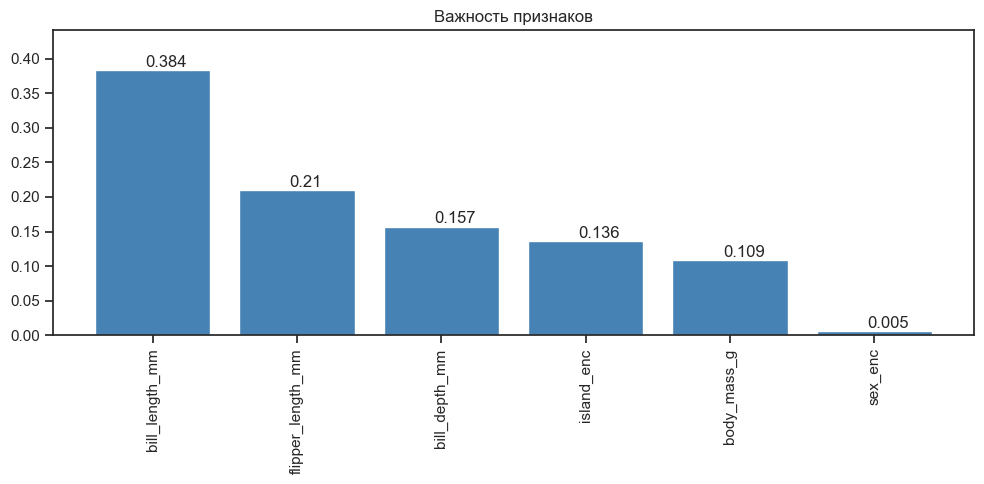

In [14]:
_, _ = draw_feature_importances(rf, X)

### 7.3 Модель 3 — AdaBoost

In [15]:
ab = AdaBoostClassifier(n_estimators=100, algorithm='SAMME', random_state=42)
ab.fit(X_train, y_train)

y_pred_ab = ab.predict(X_test)

acc_ab = accuracy_score(y_test, y_pred_ab)
f1_ab = f1_score(y_test, y_pred_ab, average='weighted')

print('AdaBoost')
print(f'Accuracy:            {acc_ab:.4f}')
print(f'F1-score (weighted): {f1_ab:.4f}')
print()
print(classification_report(y_test, y_pred_ab, target_names=le_species.classes_))

AdaBoost
Accuracy:            0.9800
F1-score (weighted): 0.9802

              precision    recall  f1-score   support

      Adelie       1.00      0.95      0.98        44
   Chinstrap       0.91      1.00      0.95        20
      Gentoo       1.00      1.00      1.00        36

    accuracy                           0.98       100
   macro avg       0.97      0.98      0.98       100
weighted avg       0.98      0.98      0.98       100



/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


### 7.4 Модель 4 — Градиентный бустинг (GradientBoostingClassifier)

In [16]:
gb = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb.fit(X_train, y_train)

y_pred_gb = gb.predict(X_test)

acc_gb = accuracy_score(y_test, y_pred_gb)
f1_gb = f1_score(y_test, y_pred_gb, average='weighted')

print('Градиентный бустинг')
print(f'Accuracy:            {acc_gb:.4f}')
print(f'F1-score (weighted): {f1_gb:.4f}')
print()
print(classification_report(y_test, y_pred_gb, target_names=le_species.classes_))

Градиентный бустинг
Accuracy:            0.9800
F1-score (weighted): 0.9802

              precision    recall  f1-score   support

      Adelie       1.00      1.00      1.00        44
   Chinstrap       0.91      1.00      0.95        20
      Gentoo       1.00      0.94      0.97        36

    accuracy                           0.98       100
   macro avg       0.97      0.98      0.97       100
weighted avg       0.98      0.98      0.98       100



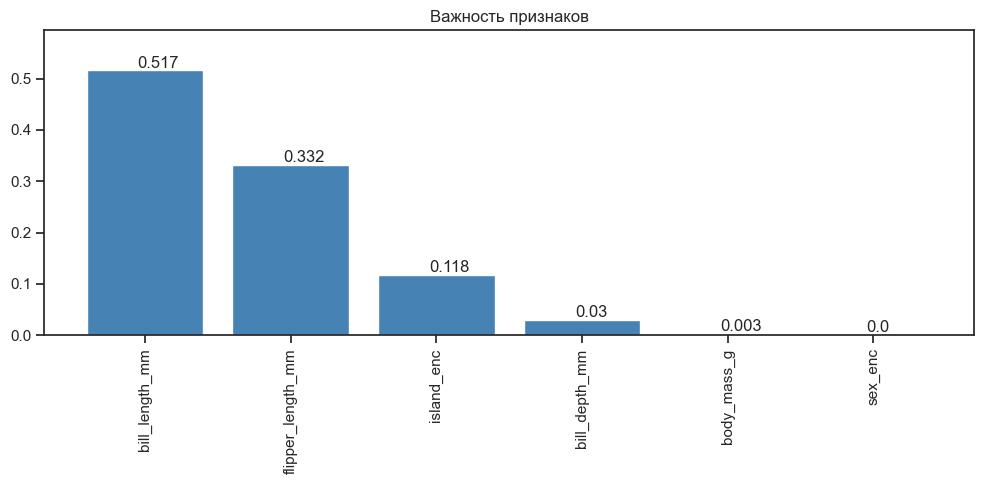

In [17]:
_, _ = draw_feature_importances(gb, X)

## 8. Сравнение качества моделей

In [18]:
results = [
    {'Модель': 'Бэггинг',              'Accuracy': acc_bc, 'F1-score (weighted)': f1_bc},
    {'Модель': 'Случайный лес',        'Accuracy': acc_rf, 'F1-score (weighted)': f1_rf},
    {'Модель': 'AdaBoost',             'Accuracy': acc_ab, 'F1-score (weighted)': f1_ab},
    {'Модель': 'Градиентный бустинг',  'Accuracy': acc_gb, 'F1-score (weighted)': f1_gb},
]

results_df = pd.DataFrame(results).sort_values('F1-score (weighted)', ascending=False).reset_index(drop=True)
results_df.style.highlight_max(subset=['Accuracy', 'F1-score (weighted)'], color='lightgreen')

,Модель,Accuracy,F1-score (weighted)
0,Бэггинг,1.000000,1.000000
1,Случайный лес,1.000000,1.000000
2,AdaBoost,0.980000,0.980244
3,Градиентный бустинг,0.980000,0.980190


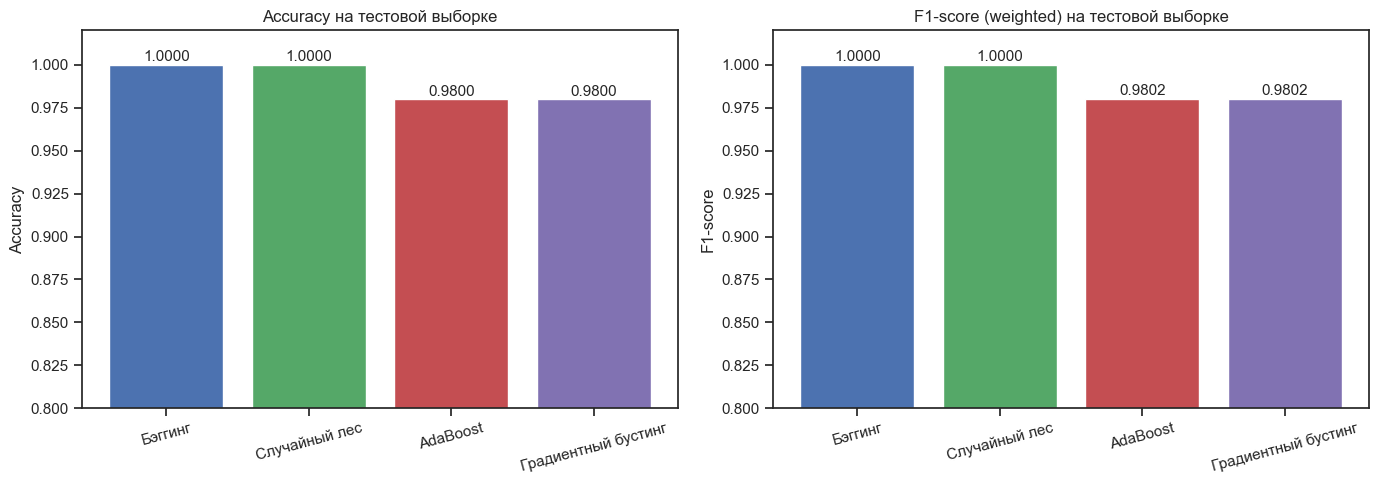

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

model_names = [r['Модель'] for r in results]
acc_values  = [r['Accuracy'] for r in results]
f1_values   = [r['F1-score (weighted)'] for r in results]
colors = ['#4C72B0', '#55A868', '#C44E52', '#8172B2']

axes[0].bar(model_names, acc_values, color=colors)
axes[0].set_title('Accuracy на тестовой выборке')
axes[0].set_ylim(0.8, 1.02)
axes[0].set_ylabel('Accuracy')
for i, v in enumerate(acc_values):
    axes[0].text(i, v + 0.002, f'{v:.4f}', ha='center', fontsize=11)
axes[0].tick_params(axis='x', rotation=15)

axes[1].bar(model_names, f1_values, color=colors)
axes[1].set_title('F1-score (weighted) на тестовой выборке')
axes[1].set_ylim(0.8, 1.02)
axes[1].set_ylabel('F1-score')
for i, v in enumerate(f1_values):
    axes[1].text(i, v + 0.002, f'{v:.4f}', ha='center', fontsize=11)
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

## 9. Выводы

По результатам эксперимента на датасете Penguins получены следующие метрики на тестовой выборке:

| Модель | Accuracy | F1-score (weighted) | Группа |
|---|---|---|---|
| Бэггинг | 1.0000 | 1.0000 | Бэггинг |
| Случайный лес | 1.0000 | 1.0000 | Бэггинг |
| AdaBoost | 0.9800 | 0.9802 | Бустинг |
| Градиентный бустинг | 0.9800 | 0.9802 | Бустинг |

**Выводы:**

1. BaggingClassifier и RandomForestClassifier показали идеальное качество (Accuracy = 1.0) на тестовой выборке. OOB-оценка (~0.97) подтверждает отсутствие переобучения, т.к. она является оценкой ошибки на данных, не попавших в бутстрэп-выборку.

2. AdaBoost и Градиентный бустинг продемонстрировали чуть меньшую точность (0.98), т.к. данный датасет хорошо разделим и не содержит сложных нелинейных паттернов — бустинг «не находит» ошибок для исправления.

3. Наиболее важные признаки по оценке Random Forest и Gradient Boosting: `flipper_length_mm` и `bill_length_mm`.